SPARQ MOMENTUM TRADING STRATEGY - REAL DATA
Machine Learning Based Long-Only Momentum Strategy
Loading data from CSV files...
  RELIANCE: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  TCS: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  INFY: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  HDFCBANK: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  ICICIBANK: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  BHARTIARTL: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  BAJFINANCE: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  HINDUNILVR: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  HCLTECH: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
  MARUTI: 2717 days (2015-01-01 00:00:00 to 2025-12-30 00:00:00)

PHASE 1: MODEL TRAINING (2015-2022)

Training Dataset:
  Samples: 17,770
  Features: 41
  Positive class (up weeks): 54.66%
  Date range: 2015-10-21 00:00:00 to 2022-12-30 00:00:00

Training Voting Classifier

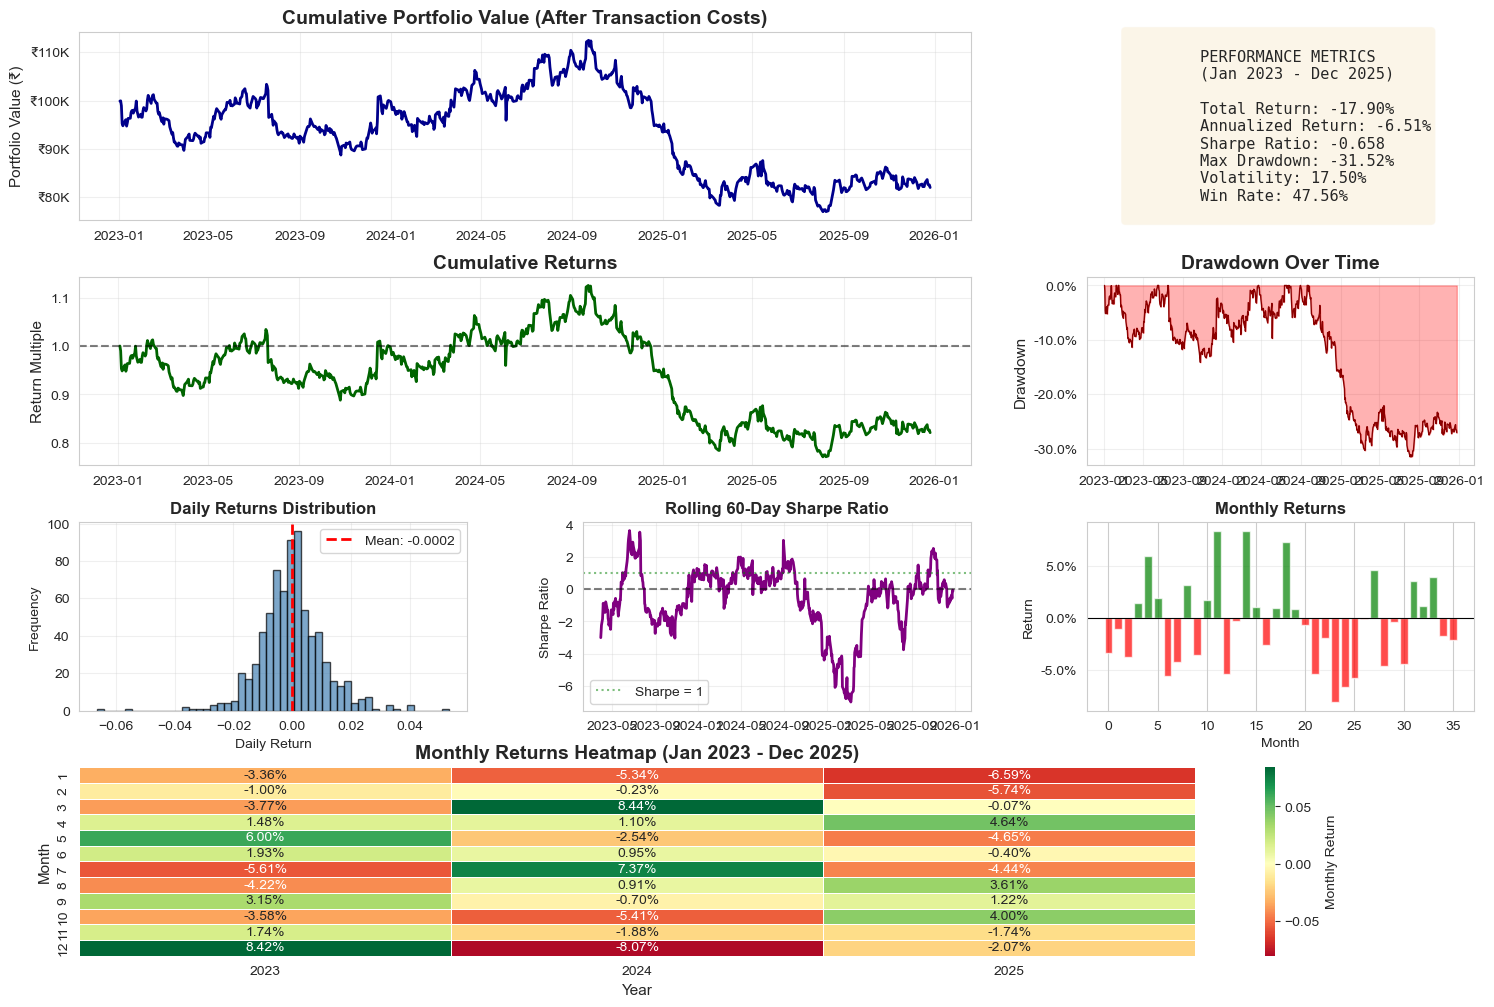

In [5]:
"""
Momentum Trading Strategy
"""

import os
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

class MomentumTradingStrategy:
    
    def __init__(self):
        os.makedirs("outputs", exist_ok=True)
        self.stock_files = {
            'RELIANCE': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\RELIANCE.csv",
            'TCS': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\TCS.csv",
            'INFY': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\INFY.csv",
            'HDFCBANK': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\HDFCBANK.csv",
            'ICICIBANK': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\ICICIBANK.csv",
            'BHARTIARTL': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\BHARTIARTL.csv",
            'BAJFINANCE': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\BAJFINANCE.csv",
            'HINDUNILVR': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\HINDUNILVR.csv",
            'HCLTECH': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\HCLTECH.csv",
            'MARUTI': r"C:\Users\ANIKET\OneDrive\Desktop\SPARQ\Indian_Stocks_OHLCV-20260110T033327Z-3-001\Indian_Stocks_OHLCV\MARUTI.csv"
        }
        
        self.train_start = '2015-01-01'
        self.train_end = '2022-12-31'
        self.test_start = '2023-01-01'
        self.test_end = '2025-12-31'
        
        self.transaction_cost = 0.001  # 10 bps per side
        self.scaler = StandardScaler()
        
    def load_data(self):
        """Load actual stock data from CSV files"""
        print("Loading data from CSV files...")
        all_data = {}
        
        for ticker, filepath in self.stock_files.items():
            try:
                df = pd.read_csv(filepath)
                
                # Parse date column
                df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
                df.set_index('Date', inplace=True)
                df.sort_index(inplace=True)
                
                # Ensure we have required columns
                required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
                if all(col in df.columns for col in required_cols):
                    all_data[ticker] = df[required_cols]
                    print(f"  {ticker}: {len(df)} days ({df.index.min()} to {df.index.max()})")
                else:
                    print(f"  {ticker}: Missing required columns")
                    
            except Exception as e:
                print(f"  Error loading {ticker}: {e}")
        
        return all_data
    
    def create_features(self, df):
        
        df = df.copy()
        
        # Returns over multiple periods
        for period in [5, 10, 21, 42, 63]:
            df[f'return_{period}d'] = df['Close'].pct_change(period)
            df[f'log_return_{period}d'] = np.log(df['Close'] / df['Close'].shift(period))
        
        # Moving averages
        for period in [5, 10, 20, 50, 200]:
            df[f'sma_{period}'] = df['Close'].rolling(window=period).mean()
            df[f'price_to_sma_{period}'] = df['Close'] / df[f'sma_{period}']
        
        # Exponential moving averages
        for period in [12, 26, 50]:
            df[f'ema_{period}'] = df['Close'].ewm(span=period, adjust=False).mean()
        
        # MACD
        df['macd'] = df['ema_12'] - df['ema_26']
        df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
        df['macd_diff'] = df['macd'] - df['macd_signal']
        
        # RSI
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Bollinger Bands
        df['bb_middle'] = df['Close'].rolling(window=20).mean()
        bb_std = df['Close'].rolling(window=20).std()
        df['bb_upper'] = df['bb_middle'] + (2 * bb_std)
        df['bb_lower'] = df['bb_middle'] - (2 * bb_std)
        df['bb_position'] = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
        df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_middle']
        
        # Volatility measures
        for period in [21, 63]:
            df[f'volatility_{period}d'] = df['Close'].pct_change().rolling(window=period).std()
        
        # High-Low features
        df['hl_ratio'] = (df['High'] - df['Low']) / df['Close']
        df['hl_ratio_ma'] = df['hl_ratio'].rolling(window=21).mean()
        
        # Volume features
        df['volume_ratio'] = df['Volume'] / df['Volume'].rolling(window=21).mean()
        df['volume_trend'] = df['Volume'].pct_change(5)
        
        # Price momentum strength
        df['momentum_strength'] = df['return_21d'] / df['volatility_21d']
        
        # Trend indicators
        for period in [5, 10, 21]:
            df[f'trend_{period}d'] = np.where(df['Close'] > df['Close'].shift(period), 1, -1)
            df[f'higher_high_{period}d'] = (df['High'] > df['High'].shift(period)).astype(int)
            df[f'higher_low_{period}d'] = (df['Low'] > df['Low'].shift(period)).astype(int)
        
        # Rate of change
        for period in [5, 10, 21, 42]:
            df[f'roc_{period}d'] = ((df['Close'] - df['Close'].shift(period)) / 
                                     df['Close'].shift(period)) * 100
        
        # Acceleration
        df['acceleration'] = df['return_5d'] - df['return_5d'].shift(5)
        
        # Volume-price relationship
        df['price_volume_corr'] = df['Close'].rolling(21).corr(df['Volume'])
        
        # Target: Next week return (binary classification)
        df['next_week_return'] = df['Close'].shift(-5).pct_change(5).shift(5)
        df['target'] = (df['next_week_return'] > 0).astype(int)
        
        return df
    
    def prepare_ml_data(self, all_data, start_date, end_date):
        
        combined_data = []
        
        for ticker, df in all_data.items():
            df_features = self.create_features(df)
            df_features['Ticker'] = ticker
            df_features = df_features[start_date:end_date]
            combined_data.append(df_features)
        
        ml_df = pd.concat(combined_data)
        ml_df = ml_df.dropna()
        
        # Select feature columns (exclude raw OHLCV and derived columns we don't want)
        exclude_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker',
                       'next_week_return', 'target', 'sma_5', 'sma_10', 'sma_20', 'sma_50', 
                       'sma_200', 'ema_12', 'ema_26', 'ema_50', 'bb_middle', 'bb_upper', 
                       'bb_lower', 'macd', 'macd_signal']
        
        feature_cols = [col for col in ml_df.columns if col not in exclude_cols]
        
        X = ml_df[feature_cols]
        y = ml_df['target']
        
        return X, y, ml_df, feature_cols
    
    def train_voting_classifier(self, X_train, y_train):
        
        print("\nTraining Voting Classifier...")
        print(f"Training on {len(X_train):,} samples with {X_train.shape[1]} features")
        
        # Base estimators with conservative parameters
        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_split=100,
            min_samples_leaf=50,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )
        
        gb = GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=4,
            min_samples_split=100,
            min_samples_leaf=50,
            subsample=0.8,
            random_state=42
        )
        
        lr = LogisticRegression(
            C=0.1,
            max_iter=1000,
            penalty='l2',
            random_state=42,
            n_jobs=-1
        )
        
        ada = AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.5,
            random_state=42
        )
        
        # Create Voting Classifier
        voting_clf = VotingClassifier(
            estimators=[
                ('rf', rf),
                ('gb', gb),
                ('lr', lr),
                ('ada', ada)
            ],
            voting='soft',
            n_jobs=-1
        )
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        
        # Time series cross-validation
        tscv = TimeSeriesSplit(n_splits=5)
        cv_scores = []
        
        print("\nCross-validation:")
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled)):
            X_fold_train = X_train_scaled[train_idx]
            y_fold_train = y_train.iloc[train_idx]
            X_fold_val = X_train_scaled[val_idx]
            y_fold_val = y_train.iloc[val_idx]
            
            voting_clf.fit(X_fold_train, y_fold_train)
            score = voting_clf.score(X_fold_val, y_fold_val)
            cv_scores.append(score)
            print(f"  Fold {fold+1}/5: Validation Accuracy = {score:.4f}")
        
        print(f"\n  Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
        
        # Final training on full dataset
        print("\nTraining final model on full training set...")
        voting_clf.fit(X_train_scaled, y_train)
        print("  Model training complete")
        
        return voting_clf
    
    def evaluate_model(self, model, X, y, dataset_name=""):
        
        X_scaled = self.scaler.transform(X)
        y_pred = model.predict(X_scaled)
        y_pred_proba = model.predict_proba(X_scaled)[:, 1]
        
        metrics = {
            'Accuracy': accuracy_score(y, y_pred),
            'Precision': precision_score(y, y_pred, zero_division=0),
            'Recall': recall_score(y, y_pred, zero_division=0),
            'F1-Score': f1_score(y, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y, y_pred_proba)
        }
        
        print(f"\n{dataset_name} Performance:")
        for metric, value in metrics.items():
            print(f"  {metric}: {value:.4f}")
        
        return metrics
    
    def backtest_strategy(self, model, all_data, start_date, end_date):
        """
        Backtest the momentum strategy
        """
        print(f"\nBacktesting from {start_date} to {end_date}...")
        
        # Get trading dates from first stock
        stocks = list(all_data.keys())
        sample_ticker = stocks[0]
        all_dates = all_data[sample_ticker][start_date:end_date].index
        
        # Weekly rebalancing dates
        weekly_dates = []
        current_week = None
        
        for date in all_dates:
            week_num = date.isocalendar()[1]
            year = date.isocalendar()[0]
            week_id = f"{year}-{week_num}"
            
            if week_id != current_week:
                weekly_dates.append(date)
                current_week = week_id
        
        print(f"  Total rebalancing dates: {len(weekly_dates)}")
        
        # Initialize portfolio
        daily_portfolio_value = pd.Series(index=all_dates, dtype=float)
        daily_portfolio_value.iloc[0] = 100000
        
        current_positions = {}
        cash = 100000
        holdings_history = []
        
        for i, rebalance_date in enumerate(weekly_dates[:-1]):
            next_rebalance = weekly_dates[i + 1]
            
            # Get predictions for all stocks
            predictions = {}
            
            for ticker in stocks:
                df = all_data[ticker]
                
                if rebalance_date not in df.index:
                    continue
                
                # Get features up to rebalance date (no look-ahead)
                df_features = self.create_features(df[:rebalance_date])
                
                if len(df_features) < 200:
                    continue
                
                # Latest features
                latest_features = df_features.iloc[-1:][self.feature_cols]
                
                if latest_features.isna().any().any():
                    continue
                
                # Predict probability
                X_scaled = self.scaler.transform(latest_features)
                prob = model.predict_proba(X_scaled)[0, 1]
                predictions[ticker] = prob
            
            if len(predictions) < 2:
                continue
            
            # Select top 2 stocks
            ranked_stocks = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
            top_2_stocks = [stock[0] for stock in ranked_stocks[:2]]
            
            # Exit current positions
            exit_value = 0
            for ticker in list(current_positions.keys()):
                shares = current_positions[ticker]
                exit_price = all_data[ticker].loc[rebalance_date, 'Close']
                exit_value += shares * exit_price * (1 - self.transaction_cost)
                del current_positions[ticker]
            
            cash += exit_value
            
            # Enter new positions (equal weight)
            position_size = cash / 2
            
            for ticker in top_2_stocks:
                entry_price = all_data[ticker].loc[rebalance_date, 'Close']
                shares = position_size / (entry_price * (1 + self.transaction_cost))
                current_positions[ticker] = shares
                cash -= position_size
            
            # Record holdings
            holdings_history.append({
                'Date': rebalance_date,
                'Stock_1': top_2_stocks[0],
                'Prob_1': predictions[top_2_stocks[0]],
                'Weight_1': 0.5,
                'Stock_2': top_2_stocks[1],
                'Prob_2': predictions[top_2_stocks[1]],
                'Weight_2': 0.5
            })
            
            # Calculate daily portfolio values
            holding_dates = all_dates[(all_dates >= rebalance_date) & (all_dates < next_rebalance)]
            
            for date in holding_dates:
                portfolio_value = cash
                for ticker, shares in current_positions.items():
                    if date in all_data[ticker].index:
                        price = all_data[ticker].loc[date, 'Close']
                        portfolio_value += shares * price
                
                daily_portfolio_value.loc[date] = portfolio_value
        
        # Clean data
        daily_portfolio_value = daily_portfolio_value.dropna()
        daily_returns = daily_portfolio_value.pct_change().dropna()
        
        print(f"  Portfolio tracking days: {len(daily_portfolio_value)}")
        print(f"  Number of rebalances: {len(holdings_history)}")
        
        return daily_portfolio_value, daily_returns, pd.DataFrame(holdings_history)
    
    def calculate_metrics(self, portfolio_values, daily_returns):
        
        # Total return
        total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0]) - 1
        
        # Annualized metrics
        trading_days = len(daily_returns)
        years = trading_days / 252
        annualized_return = (1 + total_return) ** (1 / years) - 1
        annualized_volatility = daily_returns.std() * np.sqrt(252)
        
        # Sharpe Ratio (5% risk-free rate for India)
        risk_free_rate = 0.05
        sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility if annualized_volatility > 0 else 0
        
        # Maximum Drawdown
        cumulative = (1 + daily_returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Win rate
        win_rate = (daily_returns > 0).sum() / len(daily_returns)
        
        # Monthly returns
        monthly_returns = daily_returns.resample('M').apply(lambda x: (1 + x).prod() - 1)
        
        metrics = {
            'Total Return': total_return,
            'Annualized Return': annualized_return,
            'Annualized Volatility': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Maximum Drawdown': max_drawdown,
            'Win Rate': win_rate,
            'Best Month': monthly_returns.max(),
            'Worst Month': monthly_returns.min(),
            'Positive Months': (monthly_returns > 0).sum(),
            'Total Months': len(monthly_returns)
        }
        
        return metrics, monthly_returns
    
    def create_visualizations(self, portfolio_values, daily_returns, monthly_returns):
        
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
        
        # 1. Cumulative Portfolio Value
        ax1 = fig.add_subplot(gs[0, :2])
        ax1.plot(portfolio_values.index, portfolio_values.values, linewidth=2, color='darkblue')
        ax1.set_title('Cumulative Portfolio Value (After Transaction Costs)', 
                     fontsize=14, fontweight='bold')
        ax1.set_ylabel('Portfolio Value (₹)', fontsize=11)
        ax1.grid(True, alpha=0.3)
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
        
        # 2. Key Metrics Table
        ax2 = fig.add_subplot(gs[0, 2])
        ax2.axis('off')
        
        metrics, _ = self.calculate_metrics(portfolio_values, daily_returns)
        metrics_text = f"""
        PERFORMANCE METRICS
        (Jan 2023 - Dec 2025)
        
        Total Return: {metrics['Total Return']:.2%}
        Annualized Return: {metrics['Annualized Return']:.2%}
        Sharpe Ratio: {metrics['Sharpe Ratio']:.3f}
        Max Drawdown: {metrics['Maximum Drawdown']:.2%}
        Volatility: {metrics['Annualized Volatility']:.2%}
        Win Rate: {metrics['Win Rate']:.2%}
        """
        ax2.text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
                fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
        # 3. Cumulative Returns
        ax3 = fig.add_subplot(gs[1, :2])
        cumulative_returns = (1 + daily_returns).cumprod()
        ax3.plot(cumulative_returns.index, cumulative_returns.values, 
                linewidth=2, color='darkgreen')
        ax3.set_title('Cumulative Returns', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Return Multiple', fontsize=11)
        ax3.grid(True, alpha=0.3)
        ax3.axhline(y=1, color='black', linestyle='--', alpha=0.5)
        
        # 4. Drawdown
        ax4 = fig.add_subplot(gs[1, 2])
        cumulative = (1 + daily_returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        ax4.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, color='red')
        ax4.plot(drawdown.index, drawdown.values, color='darkred', linewidth=1)
        ax4.set_title('Drawdown Over Time', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Drawdown', fontsize=11)
        ax4.grid(True, alpha=0.3)
        ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1%}'))
        
        # 5. Daily Returns Distribution
        ax5 = fig.add_subplot(gs[2, 0])
        ax5.hist(daily_returns.values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        ax5.axvline(x=daily_returns.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {daily_returns.mean():.4f}')
        ax5.set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
        ax5.set_xlabel('Daily Return', fontsize=10)
        ax5.set_ylabel('Frequency', fontsize=10)
        ax5.legend()
        ax5.grid(True, alpha=0.3)
        
        # 6. Rolling Sharpe (60-day)
        ax6 = fig.add_subplot(gs[2, 1])
        rolling_return = daily_returns.rolling(60).mean() * 252
        rolling_vol = daily_returns.rolling(60).std() * np.sqrt(252)
        rolling_sharpe = (rolling_return - 0.05) / rolling_vol
        ax6.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=2, color='purple')
        ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax6.axhline(y=1, color='green', linestyle=':', alpha=0.5, label='Sharpe = 1')
        ax6.set_title('Rolling 60-Day Sharpe Ratio', fontsize=12, fontweight='bold')
        ax6.set_ylabel('Sharpe Ratio', fontsize=10)
        ax6.legend()
        ax6.grid(True, alpha=0.3)
        
        # 7. Monthly Returns
        ax7 = fig.add_subplot(gs[2, 2])
        colors = ['green' if x > 0 else 'red' for x in monthly_returns.values]
        ax7.bar(range(len(monthly_returns)), monthly_returns.values, color=colors, alpha=0.7)
        ax7.set_title('Monthly Returns', fontsize=12, fontweight='bold')
        ax7.set_xlabel('Month', fontsize=10)
        ax7.set_ylabel('Return', fontsize=10)
        ax7.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax7.grid(True, alpha=0.3, axis='y')
        ax7.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1%}'))
        
        # 8. Monthly Returns Heatmap
        ax8 = fig.add_subplot(gs[3, :])
        monthly_pivot = monthly_returns.to_frame('Returns')
        monthly_pivot['Year'] = monthly_pivot.index.year
        monthly_pivot['Month'] = monthly_pivot.index.month
        monthly_table = monthly_pivot.pivot(index='Month', columns='Year', values='Returns')
        
        sns.heatmap(monthly_table, annot=True, fmt='.2%', cmap='RdYlGn', center=0,
                   ax=ax8, cbar_kws={'label': 'Monthly Return'}, linewidths=0.5)
        ax8.set_title('Monthly Returns Heatmap (Jan 2023 - Dec 2025)', 
                     fontsize=14, fontweight='bold')
        ax8.set_ylabel('Month', fontsize=11)
        ax8.set_xlabel('Year', fontsize=11)

        plt.savefig('outputs/backtest_performance_real.png', dpi=300, bbox_inches='tight')
        print("  Saved performance visualizations")
        
        return fig
    
    def run_complete_analysis(self):
        
        print("="*80)
        print("SPARQ MOMENTUM TRADING STRATEGY - REAL DATA")
        print("Machine Learning Based Long-Only Momentum Strategy")
        print("="*80)
        
        # Load data
        all_data = self.load_data()
        
        if len(all_data) < 10:
            print(f"\n   Warning: Only {len(all_data)} stocks loaded. Expected 10.")
        
        # Prepare training data (2015-2022)
        print("\n" + "="*80)
        print("PHASE 1: MODEL TRAINING (2015-2022)")
        print("="*80)
        
        X_train, y_train, train_df, feature_cols = self.prepare_ml_data(
            all_data, self.train_start, self.train_end
        )
        self.feature_cols = feature_cols
        
        print(f"\nTraining Dataset:")
        print(f"  Samples: {len(X_train):,}")
        print(f"  Features: {len(feature_cols)}")
        print(f"  Positive class (up weeks): {y_train.mean():.2%}")
        print(f"  Date range: {train_df.index.min()} to {train_df.index.max()}")
        
        # Train model
        model = self.train_voting_classifier(X_train, y_train)
        
        # Evaluate on training set
        train_metrics = self.evaluate_model(model, X_train, y_train, "Training Set")
        
        # Backtest on test period (2023-2025)
        print("\n" + "="*80)
        print("PHASE 2: OUT-OF-SAMPLE BACKTESTING (2023-2025)")
        print("="*80)
        
        portfolio_values, daily_returns, holdings_df = self.backtest_strategy(
            model, all_data, self.test_start, self.test_end
        )
        
        # Calculate metrics
        metrics, monthly_returns = self.calculate_metrics(portfolio_values, daily_returns)
        
        print("\n" + "="*80)
        print("FINAL RESULTS (After Transaction Costs)")
        print("="*80)
        
        print("\n  PERFORMANCE METRICS:")
        print(f"  Total Return: {metrics['Total Return']:.2%}")
        print(f"  Annualized Return: {metrics['Annualized Return']:.2%}")
        print(f"  Annualized Volatility: {metrics['Annualized Volatility']:.2%}")
        print(f"  Sharpe Ratio: {metrics['Sharpe Ratio']:.4f}")
        print(f"  Maximum Drawdown: {metrics['Maximum Drawdown']:.2%}")
        print(f"  Daily Win Rate: {metrics['Win Rate']:.2%}")
        print(f"  Best Month: {metrics['Best Month']:.2%}")
        print(f"  Worst Month: {metrics['Worst Month']:.2%}")
        print(f"  Positive Months: {metrics['Positive Months']}/{metrics['Total Months']}")
        
        # Create visualizations
        self.create_visualizations(portfolio_values, daily_returns, monthly_returns)
        
        # Save outputs
        print("\n  Saving outputs...")

        holdings_df.to_csv('outputs/portfolio_weights_real.csv', index=False)
        print("    portfolio_weights_real.csv")
        
        performance_df = pd.DataFrame({
            'Date': portfolio_values.index,
            'Portfolio_Value': portfolio_values.values,
            'Daily_Return': [0] + list(daily_returns.values)
        })
        performance_df.to_csv('outputs/performance_real.csv', index=False)
        print("    daily_performance_real.csv")
        
        monthly_df = monthly_returns.to_frame('Monthly_Return')
        monthly_df['Year'] = monthly_df.index.year
        monthly_df['Month'] = monthly_df.index.month
        monthly_df.to_csv('outputs/monthly_returns_real.csv', index=False)
        print("    monthly_returns_real.csv")
        
        metrics_df = pd.DataFrame([metrics])
        metrics_df.to_csv('outputs/monthly_returns_real.csv', index=False)
        print("    performance_metrics_real.csv")
        
        print("\n" + "="*80)
        print("  ANALYSIS COMPLETE!")
        print("="*80)
        
        return model, portfolio_values, daily_returns, holdings_df, metrics

if __name__ == "__main__":
    strategy = MomentumTradingStrategy()
    results = strategy.run_complete_analysis()
